In [11]:
# ============================================================
# 0. IMPORTS & SETUP
# ============================================================
import os
import torch
import torch.nn as nn
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image
from torch.utils.data import Dataset, DataLoader
from torchvision import models, transforms
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, f1_score, confusion_matrix, ConfusionMatrixDisplay
from sklearn.manifold import TSNE
from copy import deepcopy

device = "cuda" if torch.cuda.is_available() else "cpu"




In [12]:
# ============================================================
# 1. DATA LOADING
# ============================================================
def load_casting_images(root):
    img_paths, labels = [], []
    for label, cls in enumerate(["ok_front", "def_front"]):
        cls_path = os.path.join(root, cls)
        if not os.path.exists(cls_path): continue
        for f in os.listdir(cls_path):
            img_paths.append(os.path.join(cls_path, f))
            labels.append(label)
    return img_paths, labels

train_root = "/kaggle/input/real-life-industrial-dataset-of-casting-product/casting_data/casting_data/train"
test_root  = "/kaggle/input/real-life-industrial-dataset-of-casting-product/casting_data/casting_data/test"

train_imgs, train_lbls = load_casting_images(train_root)
test_imgs, test_lbls = load_casting_images(test_root)

all_imgs = train_imgs + test_imgs
all_lbls = train_lbls + test_lbls

# %80 SSL (Etiketsiz) - %20 Sınıflandırma Split
ssl_imgs, cls_imgs, _, cls_lbls = train_test_split(
    all_imgs, all_lbls, test_size=0.20, stratify=all_lbls, random_state=42
)

# Sınıflandırma için Train/Test Ayırımı
cls_train_imgs, cls_test_imgs, cls_train_lbls, cls_test_lbls = train_test_split(
    cls_imgs, cls_lbls, test_size=0.20, stratify=cls_lbls, random_state=42
)


In [13]:
# ============================================================
# 2. TRANSFORMS & DATASETS
# ============================================================
ssl_transform = transforms.Compose([
    transforms.RandomResizedCrop(224, scale=(0.2, 1.0)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomApply([transforms.ColorJitter(0.4, 0.4, 0.4, 0.1)], p=0.8),
    transforms.RandomGrayscale(p=0.2),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
])

cls_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
])

class SSLDataset(Dataset):
    def __init__(self, img_paths, transform):
        self.img_paths = img_paths
        self.transform = transform
    def __len__(self): return len(self.img_paths)
    def __getitem__(self, idx):
        img = Image.open(self.img_paths[idx]).convert("RGB")
        return self.transform(img), self.transform(img)

class ClsDataset(Dataset):
    def __init__(self, img_paths, labels, transform):
        self.img_paths = img_paths
        self.labels = labels
        self.transform = transform
    def __len__(self): return len(self.img_paths)
    def __getitem__(self, idx):
        img = Image.open(self.img_paths[idx]).convert("RGB")
        return self.transform(img), self.labels[idx]

ssl_loader = DataLoader(SSLDataset(ssl_imgs, ssl_transform), batch_size=128, shuffle=True, num_workers=4, pin_memory=True)
cls_train_loader = DataLoader(ClsDataset(cls_train_imgs, cls_train_lbls, cls_transform), batch_size=32, shuffle=True)
cls_test_loader = DataLoader(ClsDataset(cls_test_imgs, cls_test_lbls, cls_transform), batch_size=32)



In [14]:
# ============================================================
# 3. SIMSIAM MODEL & LOSS
# ============================================================
class SimSiam(nn.Module):
    def __init__(self):
        super().__init__()
        base = models.resnet18(weights=None)
        self.encoder = nn.Sequential(*list(base.children())[:-1])
        self.projector = nn.Sequential(
            nn.Linear(512, 512), nn.BatchNorm1d(512), nn.ReLU(),
            nn.Linear(512, 512), nn.BatchNorm1d(512), nn.ReLU(),
            nn.Linear(512, 2048), nn.BatchNorm1d(2048, affine=False)
        )
        self.predictor = nn.Sequential(
            nn.Linear(2048, 512), nn.BatchNorm1d(512), nn.ReLU(),
            nn.Linear(512, 2048)
        )

    def forward(self, x1, x2):
        z1 = self.projector(self.encoder(x1).squeeze())
        z2 = self.projector(self.encoder(x2).squeeze())
        p1 = self.predictor(z1)
        p2 = self.predictor(z2)
        return p1, p2, z1, z2

def simsiam_loss(p, z):
    z = z.detach() 
    p = nn.functional.normalize(p, dim=1)
    z = nn.functional.normalize(z, dim=1)
    return -(p * z).sum(dim=1).mean()



In [15]:
# ============================================================
# 4. SSL PRETRAINING (SIMSIAM)
# ============================================================

ssl_model = SimSiam().to(device)
optimizer = torch.optim.Adam(ssl_model.parameters(), lr=1e-3, weight_decay=1e-4)

# Early Stopping Ayarları
SSL_EPOCHS = 50 
patience = 10  # Kayıp 10 epoch boyunca iyileşmezse eğitimi durdur
best_loss = float('inf')
counter = 0
ssl_losses = []

print(" SSL Ön Eğitimi Başlıyor (SimSiam + Early Stopping)...")
for epoch in range(SSL_EPOCHS):
    ssl_model.train()
    epoch_loss = 0
    for x1, x2 in ssl_loader:
        x1, x2 = x1.to(device), x2.to(device)
        p1, p2, z1, z2 = ssl_model(x1, x2)
        
        # SimSiam simetrik kayıp hesaplaması
        loss = (simsiam_loss(p1, z2) + simsiam_loss(p2, z1)) * 0.5
        
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
        epoch_loss += loss.item()
    
    avg_l = epoch_loss / len(ssl_loader)
    ssl_losses.append(avg_l)
    print(f"Epoch [{epoch+1}/{SSL_EPOCHS}] Loss: {avg_l:.4f}")

    # --- Early Stopping Kontrolü ---
    if avg_l < best_loss:
        best_loss = avg_l
        counter = 0  # Daha iyi bir kayıp bulduk, sayacı sıfırla
        # En iyi modelin ağırlıklarını sakla
        best_model_state = deepcopy(ssl_model.state_dict())
    else:
        counter += 1
        if counter >= patience:
            print(f" Early Stopping: {patience} epoch boyunca iyileşme olmadı. Eğitim durduruldu.")
            ssl_model.load_state_dict(best_model_state) # En iyi ağırlıklara geri dön
            break


 SSL Ön Eğitimi Başlıyor (SimSiam + Early Stopping)...
Epoch [1/50] Loss: -0.6291
Epoch [2/50] Loss: -0.8315
Epoch [3/50] Loss: -0.7940
Epoch [4/50] Loss: -0.6017
Epoch [5/50] Loss: -0.6432
Epoch [6/50] Loss: -0.6072
Epoch [7/50] Loss: -0.8214
Epoch [8/50] Loss: -0.8663
Epoch [9/50] Loss: -0.8206
Epoch [10/50] Loss: -0.7517
Epoch [11/50] Loss: -0.5737
Epoch [12/50] Loss: -0.7155
Epoch [13/50] Loss: -0.8243
Epoch [14/50] Loss: -0.8396
Epoch [15/50] Loss: -0.8832
Epoch [16/50] Loss: -0.7541
Epoch [17/50] Loss: -0.8290
Epoch [18/50] Loss: -0.7867
Epoch [19/50] Loss: -0.8303
Epoch [20/50] Loss: -0.8340
Epoch [21/50] Loss: -0.8324
Epoch [22/50] Loss: -0.8369
Epoch [23/50] Loss: -0.8584
Epoch [24/50] Loss: -0.8728
Epoch [25/50] Loss: -0.7058
 Early Stopping: 10 epoch boyunca iyileşme olmadı. Eğitim durduruldu.


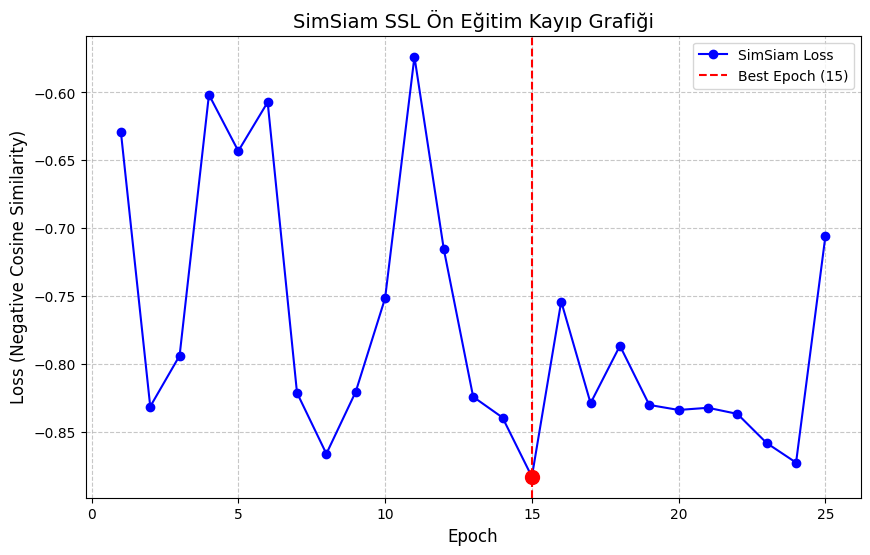

In [17]:
import matplotlib.pyplot as plt

# Senin verilerin
losses = [-0.6291, -0.8315, -0.7940, -0.6017, -0.6432, -0.6072, -0.8214, -0.8663, 
          -0.8206, -0.7517, -0.5737, -0.7155, -0.8243, -0.8396, -0.8832, -0.7541, 
          -0.8290, -0.7867, -0.8303, -0.8340, -0.8324, -0.8369, -0.8584, -0.8728, -0.7058]

epochs = range(1, len(losses) + 1)
best_epoch = losses.index(min(losses)) + 1
best_loss = min(losses)

plt.figure(figsize=(10, 6))
plt.plot(epochs, losses, marker='o', linestyle='-', color='b', label='SimSiam Loss')
plt.axvline(x=best_epoch, color='r', linestyle='--', label=f'Best Epoch ({best_epoch})')
plt.scatter(best_epoch, best_loss, color='red', s=100, zorder=5) # En iyi noktayı işaretle

plt.title('SimSiam SSL Ön Eğitim Kayıp Grafiği', fontsize=14)
plt.xlabel('Epoch', fontsize=12)
plt.ylabel('Loss (Negative Cosine Similarity)', fontsize=12)
plt.legend()
plt.grid(True, linestyle='--', alpha=0.7)

# Sunum için arka planı beyaz yapalım
plt.gca().set_facecolor('white')
plt.show()

In [56]:
# ============================================================
# 5. CLASSIFIER MODEL VE EĞİTİM
# ============================================================
class Classifier(nn.Module):
    def __init__(self, encoder):
        super().__init__()
        self.encoder = encoder
        self.fc = nn.Linear(512, 2)
    
    def forward(self, x):
        features = self.encoder(x).squeeze()
        return self.fc(features)

# En iyi modeli hazırla
final_model = Classifier(deepcopy(ssl_model.encoder)).to(device)
criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(final_model.parameters(), lr=1e-4, weight_decay=1e-4)

# Eğitim metrikleri
train_losses = []
train_accs = []
val_accs = []

print("\n🎯 Sınıflandırma Modeli Eğitimi Başlıyor...")
EPOCHS = 30
best_val_acc = 0.0

for epoch in range(EPOCHS):
    # Training
    final_model.train()
    running_loss = 0.0
    correct = 0
    total = 0
    
    for x, y in cls_train_loader:
        x, y = x.to(device), y.to(device)
        outputs = final_model(x)
        loss = criterion(outputs, y)
        
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
        
        running_loss += loss.item()
        _, predicted = outputs.max(1)
        total += y.size(0)
        correct += predicted.eq(y).sum().item()
    
    epoch_loss = running_loss / len(cls_train_loader)
    train_acc = 100. * correct / total
    train_losses.append(epoch_loss)
    train_accs.append(train_acc)
    
    # Validation
    final_model.eval()
    correct = 0
    total = 0
    with torch.no_grad():
        for x, y in cls_test_loader:
            x, y = x.to(device), y.to(device)
            outputs = final_model(x)
            _, predicted = outputs.max(1)
            total += y.size(0)
            correct += predicted.eq(y).sum().item()
    
    val_acc = 100. * correct / total
    val_accs.append(val_acc)
    
    if val_acc > best_val_acc:
        best_val_acc = val_acc
        best_model_weights = deepcopy(final_model.state_dict())
    
    print(f"Epoch [{epoch+1}/{EPOCHS}] Loss: {epoch_loss:.4f} | Train Acc: {train_acc:.2f}% | Val Acc: {val_acc:.2f}%")

# En iyi modeli yükle
final_model.load_state_dict(best_model_weights)
print(f"\n✅ En İyi Validasyon Doğruluğu: {best_val_acc:.2f}%")





🎯 Sınıflandırma Modeli Eğitimi Başlıyor...
Epoch [1/30] Loss: 0.6109 | Train Acc: 78.74% | Val Acc: 89.80%
Epoch [2/30] Loss: 0.4787 | Train Acc: 89.71% | Val Acc: 89.80%
Epoch [3/30] Loss: 0.4022 | Train Acc: 89.20% | Val Acc: 89.46%
Epoch [4/30] Loss: 0.3508 | Train Acc: 89.97% | Val Acc: 89.12%
Epoch [5/30] Loss: 0.3298 | Train Acc: 89.54% | Val Acc: 89.80%
Epoch [6/30] Loss: 0.3046 | Train Acc: 90.39% | Val Acc: 89.80%
Epoch [7/30] Loss: 0.3066 | Train Acc: 88.95% | Val Acc: 90.14%
Epoch [8/30] Loss: 0.2829 | Train Acc: 90.56% | Val Acc: 90.14%
Epoch [9/30] Loss: 0.2948 | Train Acc: 89.71% | Val Acc: 90.14%
Epoch [10/30] Loss: 0.2788 | Train Acc: 89.37% | Val Acc: 89.46%
Epoch [11/30] Loss: 0.2643 | Train Acc: 90.39% | Val Acc: 89.80%
Epoch [12/30] Loss: 0.2723 | Train Acc: 89.63% | Val Acc: 90.14%
Epoch [13/30] Loss: 0.2737 | Train Acc: 89.97% | Val Acc: 88.78%
Epoch [14/30] Loss: 0.2670 | Train Acc: 89.71% | Val Acc: 89.80%
Epoch [15/30] Loss: 0.2562 | Train Acc: 90.65% | Val Ac


 Veri Seti Örnekleri Görselleştiriliyor...


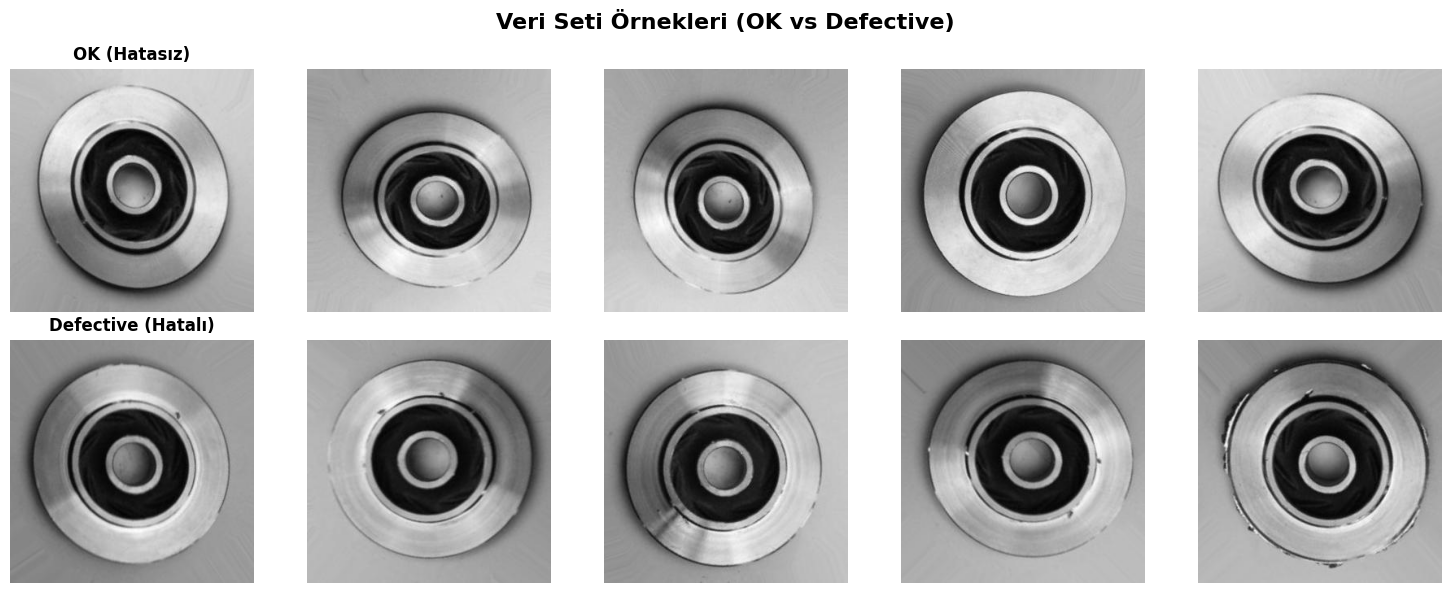

In [58]:
# ============================================================
# 7. VERİ SETİ GÖRSELLEŞTİRME
# ============================================================
print("\n Veri Seti Örnekleri Görselleştiriliyor...")

fig, axes = plt.subplots(2, 5, figsize=(15, 6))
fig.suptitle('Veri Seti Örnekleri (OK vs Defective)', fontsize=16, fontweight='bold')

class_names = ['OK (Hatasız)', 'Defective (Hatalı)']
samples_per_class = 5

for class_idx in range(2):
    class_imgs = [img for img, lbl in zip(cls_train_imgs, cls_train_lbls) if lbl == class_idx]
    selected = np.random.choice(class_imgs, samples_per_class, replace=False)
    
    for i, img_path in enumerate(selected):
        img = Image.open(img_path).convert('RGB')
        axes[class_idx, i].imshow(img)
        axes[class_idx, i].axis('off')
        if i == 0:
            axes[class_idx, i].set_title(class_names[class_idx], fontsize=12, fontweight='bold')

plt.tight_layout()
plt.show()




In [135]:
# ============================================================
# 5. CLASSIFIER MODEL
# ============================================================
class Classifier(nn.Module):
    def __init__(self, encoder):
        super().__init__()
        self.encoder = encoder
        self.fc = nn.Linear(512, 2)
    
    def forward(self, x):
        features = self.encoder(x).squeeze()
        return self.fc(features)

In [136]:


# ============================================================
# 6. HİPERPARAMETRE OPTİMİZASYONU (Grid Search)
# ============================================================
import itertools
from copy import deepcopy

# Denenecek hiperparametre havuzu
lrs = [1e-3, 1e-4, 1e-5]
wds = [1e-3, 1e-4, 1e-5]
batch_sizes = [32]  # İsterseniz [16, 32, 64] gibi genişletebilirsiniz

HYPERPARAM_EPOCHS = 20  # Her kombinasyon için epoch sayısı
best_val_acc = 0.0
best_config = {}
all_results = []

criterion = nn.CrossEntropyLoss()

print("\n" + "="*70)
print("🚀 HİPERPARAMETRE OPTİMİZASYONU BAŞLIYOR (Grid Search)")
print("="*70)
print(f"Toplam Kombinasyon: {len(lrs) * len(wds) * len(batch_sizes)}")
print(f"Her Kombinasyon için Epoch: {HYPERPARAM_EPOCHS}")
print("="*70 + "\n")

# Tüm kombinasyonları dene
for combo_idx, (lr, wd, bs) in enumerate(itertools.product(lrs, wds, batch_sizes), 1):
    print(f"\n{'='*70}")
    print(f"[{combo_idx}/{len(lrs)*len(wds)*len(batch_sizes)}] Deneniyor: LR={lr}, WD={wd}, Batch Size={bs}")
    print(f"{'='*70}")
    
    # DataLoader'ı batch size'a göre yeniden oluştur
    if bs != 32:
        temp_train_loader = DataLoader(
            ClsDataset(cls_train_imgs, cls_train_lbls, cls_transform), 
            batch_size=bs, shuffle=True
        )
        temp_test_loader = DataLoader(
            ClsDataset(cls_test_imgs, cls_test_lbls, cls_transform), 
            batch_size=bs
        )
    else:
        temp_train_loader = cls_train_loader
        temp_test_loader = cls_test_loader
    
    # Her seferinde SSL'den gelen temiz encoder ile başla
    temp_model = Classifier(deepcopy(ssl_model.encoder)).to(device)
    optimizer = torch.optim.Adam(temp_model.parameters(), lr=lr, weight_decay=wd)
    
    # Bu kombinasyon için eğitim metrikleri
    combo_train_accs = []
    combo_val_accs = []
    combo_train_losses = []
    
    for epoch in range(HYPERPARAM_EPOCHS):
        # Training
        temp_model.train()
        running_loss = 0.0
        correct = 0
        total = 0
        
        for x, y in temp_train_loader:
            x, y = x.to(device), y.to(device)
            outputs = temp_model(x)
            loss = criterion(outputs, y)
            
            optimizer.zero_grad()
            loss.backward()
            optimizer.step()
            
            running_loss += loss.item()
            _, predicted = outputs.max(1)
            total += y.size(0)
            correct += predicted.eq(y).sum().item()
        
        epoch_loss = running_loss / len(temp_train_loader)
        train_acc = 100. * correct / total
        combo_train_losses.append(epoch_loss)
        combo_train_accs.append(train_acc)
        
        # Validation
        temp_model.eval()
        correct = 0
        total = 0
        with torch.no_grad():
            for x, y in temp_test_loader:
                x, y = x.to(device), y.to(device)
                outputs = temp_model(x)
                _, predicted = outputs.max(1)
                total += y.size(0)
                correct += predicted.eq(y).sum().item()
        
        val_acc = 100. * correct / total
        combo_val_accs.append(val_acc)
        
        # Her 5 epoch'ta bir progress göster
        if (epoch + 1) % 5 == 0:
            print(f"  Epoch [{epoch+1}/{HYPERPARAM_EPOCHS}] "
                  f"Loss: {epoch_loss:.4f} | "
                  f"Train Acc: {train_acc:.2f}% | "
                  f"Val Acc: {val_acc:.2f}%")
    
    # Bu kombinasyonun final val accuracy'si
    final_val_acc = combo_val_accs[-1]
    
    # Sonuçları kaydet
    result = {
        'lr': lr,
        'wd': wd,
        'batch_size': bs,
        'final_val_acc': final_val_acc,
        'best_val_acc': max(combo_val_accs),
        'train_accs': combo_train_accs,
        'val_accs': combo_val_accs,
        'train_losses': combo_train_losses
    }
    all_results.append(result)
    
    print(f"\n  📊 Sonuç: Final Val Acc = {final_val_acc:.2f}% | "
          f"Best Val Acc = {max(combo_val_accs):.2f}%")
    
    # En iyi modeli kaydet
    if max(combo_val_accs) > best_val_acc:
        best_val_acc = max(combo_val_accs)
        best_config = {'lr': lr, 'wd': wd, 'batch_size': bs}
        best_model_weights = deepcopy(temp_model.state_dict())
        print(f"  ✨ Yeni En İyi Model! (Val Acc: {best_val_acc:.2f}%)")

print("\n" + "="*70)
print("✅ HİPERPARAMETRE OPTİMİZASYONU TAMAMLANDI!")
print("="*70)
print(f"\n🏆 EN İYİ SONUÇLAR:")
print(f"  • Learning Rate:    {best_config['lr']}")
print(f"  • Weight Decay:     {best_config['wd']}")
print(f"  • Batch Size:       {best_config['batch_size']}")
print(f"  • Best Val Acc:     {best_val_acc:.2f}%")
print("="*70)





🚀 HİPERPARAMETRE OPTİMİZASYONU BAŞLIYOR (Grid Search)
Toplam Kombinasyon: 9
Her Kombinasyon için Epoch: 20


[1/9] Deneniyor: LR=0.001, WD=0.001, Batch Size=32
  Epoch [5/20] Loss: 0.2685 | Train Acc: 89.71% | Val Acc: 89.80%
  Epoch [10/20] Loss: 0.2597 | Train Acc: 90.31% | Val Acc: 89.80%
  Epoch [15/20] Loss: 0.2516 | Train Acc: 90.65% | Val Acc: 89.80%
  Epoch [20/20] Loss: 0.2426 | Train Acc: 90.90% | Val Acc: 89.80%

  📊 Sonuç: Final Val Acc = 89.80% | Best Val Acc = 90.48%
  ✨ Yeni En İyi Model! (Val Acc: 90.48%)

[2/9] Deneniyor: LR=0.001, WD=0.0001, Batch Size=32
  Epoch [5/20] Loss: 0.2650 | Train Acc: 89.54% | Val Acc: 89.12%
  Epoch [10/20] Loss: 0.2699 | Train Acc: 89.03% | Val Acc: 89.12%
  Epoch [15/20] Loss: 0.2582 | Train Acc: 90.82% | Val Acc: 89.46%
  Epoch [20/20] Loss: 0.2575 | Train Acc: 89.80% | Val Acc: 89.46%

  📊 Sonuç: Final Val Acc = 89.46% | Best Val Acc = 90.48%

[3/9] Deneniyor: LR=0.001, WD=1e-05, Batch Size=32
  Epoch [5/20] Loss: 0.2778 | Train Acc: 

In [258]:
# ============================================================
# 7. EN İYİ MODELİ YÜKLE VE DETAYLI EĞİT--eski
# ============================================================
print("\n" + "="*70)
print("🎯 EN İYİ HİPERPARAMETRELERLE DETAYLI EĞİTİM BAŞLIYOR")
print("="*70)

# En iyi konfigürasyonla model oluştur
final_model = Classifier(deepcopy(ssl_model.encoder)).to(device)
final_model.load_state_dict(best_model_weights)

# En iyi batch size ile DataLoader oluştur
if best_config['batch_size'] != 32:
    final_train_loader = DataLoader(
        ClsDataset(cls_train_imgs, cls_train_lbls, cls_transform), 
        batch_size=best_config['batch_size'], shuffle=True
    )
    final_test_loader = DataLoader(
        ClsDataset(cls_test_imgs, cls_test_lbls, cls_transform), 
        batch_size=best_config['batch_size']
    )
else:
    final_train_loader = cls_train_loader
    final_test_loader = cls_test_loader

optimizer = torch.optim.Adam(
    final_model.parameters(), 
    lr=best_config['lr'], 
    weight_decay=best_config['wd']
)

# Final eğitim metrikleri
train_losses = []
train_accs = []
val_accs = []

FINAL_EPOCHS = 50
best_final_val_acc = 0.0
patience = 10
counter = 0

for epoch in range(FINAL_EPOCHS):
    # Training
    final_model.train()
    running_loss = 0.0
    correct = 0
    total = 0
    
    for x, y in final_train_loader:
        x, y = x.to(device), y.to(device)
        outputs = final_model(x)
        loss = criterion(outputs, y)
        
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
        
        running_loss += loss.item()
        _, predicted = outputs.max(1)
        total += y.size(0)
        correct += predicted.eq(y).sum().item()
    
    epoch_loss = running_loss / len(final_train_loader)
    train_acc = 100. * correct / total
    train_losses.append(epoch_loss)
    train_accs.append(train_acc)
    
    # Validation
    final_model.eval()
    correct = 0
    total = 0
    with torch.no_grad():
        for x, y in final_test_loader:
            x, y = x.to(device), y.to(device)
            outputs = final_model(x)
            _, predicted = outputs.max(1)
            total += y.size(0)
            correct += predicted.eq(y).sum().item()
    
    val_acc = 100. * correct / total
    val_accs.append(val_acc)
    
    print(f"Epoch [{epoch+1}/{FINAL_EPOCHS}] "
          f"Loss: {epoch_loss:.4f} | "
          f"Train Acc: {train_acc:.2f}% | "
          f"Val Acc: {val_acc:.2f}%")
    
    # En iyi modeli kaydet
    if val_acc > best_final_val_acc:
        best_final_val_acc = val_acc
        best_final_weights = deepcopy(final_model.state_dict())
        counter = 0
        print(f"  ✨ Yeni En İyi! Val Acc: {val_acc:.2f}%")
    else:
        counter += 1
        if counter >= patience:
            print(f"\n⏸ Early Stopping: {patience} epoch boyunca iyileşme olmadı.")
            break

# En iyi modeli yükle
final_model.load_state_dict(best_final_weights)

print("\n" + "="*70)
print("✅ EĞİTİM TAMAMLANDI!")
print("="*70)
print(f"  • En İyi Validasyon Doğruluğu: {best_final_val_acc:.2f}%")
print(f"  • Toplam Epoch: {len(train_losses)}")
print("="*70)


🎯 EN İYİ HİPERPARAMETRELERLE DETAYLI EĞİTİM BAŞLIYOR
Epoch [1/50] Loss: 0.2562 | Train Acc: 90.31% | Val Acc: 89.80%
  ✨ Yeni En İyi! Val Acc: 89.80%
Epoch [2/50] Loss: 0.2712 | Train Acc: 90.31% | Val Acc: 89.80%
Epoch [3/50] Loss: 0.2598 | Train Acc: 89.97% | Val Acc: 89.80%
Epoch [4/50] Loss: 0.2587 | Train Acc: 89.97% | Val Acc: 90.82%
  ✨ Yeni En İyi! Val Acc: 90.82%
Epoch [5/50] Loss: 0.2493 | Train Acc: 90.56% | Val Acc: 89.80%
Epoch [6/50] Loss: 0.2343 | Train Acc: 90.73% | Val Acc: 89.12%
Epoch [7/50] Loss: 0.2479 | Train Acc: 91.07% | Val Acc: 90.14%
Epoch [8/50] Loss: 0.2481 | Train Acc: 90.65% | Val Acc: 89.80%
Epoch [9/50] Loss: 0.2606 | Train Acc: 89.80% | Val Acc: 89.80%
Epoch [10/50] Loss: 0.2528 | Train Acc: 90.65% | Val Acc: 89.80%
Epoch [11/50] Loss: 0.2607 | Train Acc: 90.73% | Val Acc: 90.48%
Epoch [12/50] Loss: 0.2638 | Train Acc: 89.03% | Val Acc: 89.46%
Epoch [13/50] Loss: 0.2567 | Train Acc: 90.05% | Val Acc: 89.80%
Epoch [14/50] Loss: 0.2500 | Train Acc: 90.9


📈 Eğitim Grafikleri Oluşturuluyor...


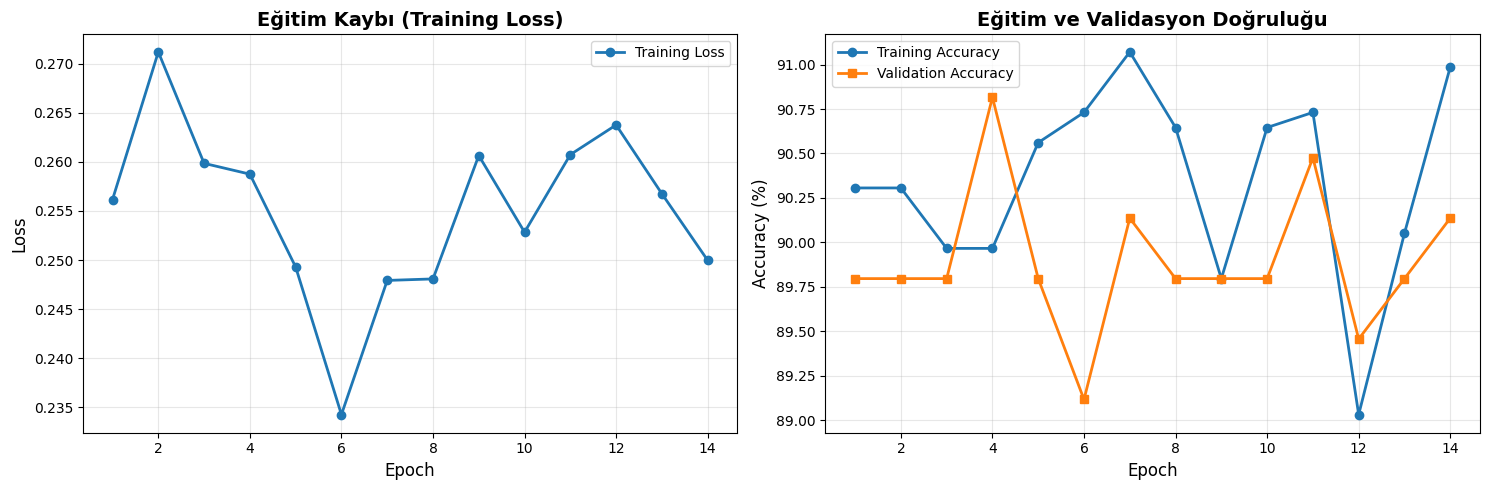

In [259]:
# ============================================================
# 8. EĞİTİM GRAFİKLERİ
# ============================================================
print("\n📈 Eğitim Grafikleri Oluşturuluyor...")

fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# Loss grafiği
axes[0].plot(range(1, len(train_losses) + 1), train_losses, marker='o', label='Training Loss', linewidth=2)
axes[0].set_xlabel('Epoch', fontsize=12)
axes[0].set_ylabel('Loss', fontsize=12)
axes[0].set_title('Eğitim Kaybı (Training Loss)', fontsize=14, fontweight='bold')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Accuracy grafiği
axes[1].plot(range(1, len(train_accs) + 1), train_accs, marker='o', label='Training Accuracy', linewidth=2)
axes[1].plot(range(1, len(val_accs) + 1), val_accs, marker='s', label='Validation Accuracy', linewidth=2)
axes[1].set_xlabel('Epoch', fontsize=12)
axes[1].set_ylabel('Accuracy (%)', fontsize=12)
axes[1].set_title('Eğitim ve Validasyon Doğruluğu', fontsize=14, fontweight='bold')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()


In [295]:
# ============================================================
# 6. DETAYLI METRİK HESAPLAMA
# ============================================================
def calculate_metrics(model, loader, device):
    model.eval()
    all_preds = []
    all_labels = []
    all_probs = []
    
    with torch.no_grad():
        for x, y in loader:
            x, y = x.to(device), y.to(device)
            outputs = model(x)
            probs = torch.softmax(outputs, dim=1)
            _, predicted = outputs.max(1)
            
            all_preds.extend(predicted.cpu().numpy())
            all_labels.extend(y.cpu().numpy())
            all_probs.extend(probs[:, 1].cpu().numpy())  # Positive class probability
    
    all_preds = np.array(all_preds)
    all_labels = np.array(all_labels)
    all_probs = np.array(all_probs)
    
    # Accuracy
    accuracy = accuracy_score(all_labels, all_preds)
    
    # F1 Score
    f1 = f1_score(all_labels, all_preds, average='binary')
    
    # Confusion Matrix için TP, TN, FP, FN
    cm = confusion_matrix(all_labels, all_preds)
    tn, fp, fn, tp = cm.ravel()
    
    # IoU (Intersection over Union) - Defective class için
    iou = tp / (tp + fp + fn) if (tp + fp + fn) > 0 else 0
    
    # Dice Coefficient (F1 Score ile aynı)
    dice = 2 * tp / (2 * tp + fp + fn) if (2 * tp + fp + fn) > 0 else 0
    
    # Precision ve Recall
    precision = tp / (tp + fp) if (tp + fp) > 0 else 0
    recall = tp / (tp + fn) if (tp + fn) > 0 else 0
    
    # Specificity
    specificity = tn / (tn + fp) if (tn + fp) > 0 else 0
    
    return {
        'accuracy': accuracy,
        'f1_score': f1,
        'iou': iou,
        'dice': dice,
        'precision': precision,
        'recall': recall,
        'specificity': specificity,
        'confusion_matrix': cm,
        'predictions': all_preds,
        'labels': all_labels,
        'probabilities': all_probs
    }

print("\n📊 Test Seti Metrikleri Hesaplanıyor...")
test_metrics = calculate_metrics(final_model, cls_test_loader, device)

print("\n" + "="*60)
print("           TEST SETİ PERFORMANS METRİKLERİ")
print("="*60)
print(f"  Accuracy:      {test_metrics['accuracy']*100:.2f}%")
print(f"  F1 Score:      {test_metrics['f1_score']:.4f}")
print(f"  IoU:           {test_metrics['iou']:.4f}")
print(f"  Dice Coeff:    {test_metrics['dice']:.4f}")
print(f"  Precision:     {test_metrics['precision']:.4f}")
print(f"  Recall:        {test_metrics['recall']:.4f}")
print(f"  Specificity:   {test_metrics['specificity']:.4f}")
print("="*60)



📊 Test Seti Metrikleri Hesaplanıyor...

           TEST SETİ PERFORMANS METRİKLERİ
  Accuracy:      90.82%
  F1 Score:      0.9194
  IoU:           0.8508
  Dice Coeff:    0.9194
  Precision:     0.9222
  Recall:        0.9167
  Specificity:   0.8968



🎨 t-SNE ile Feature Space Görselleştiriliyor...


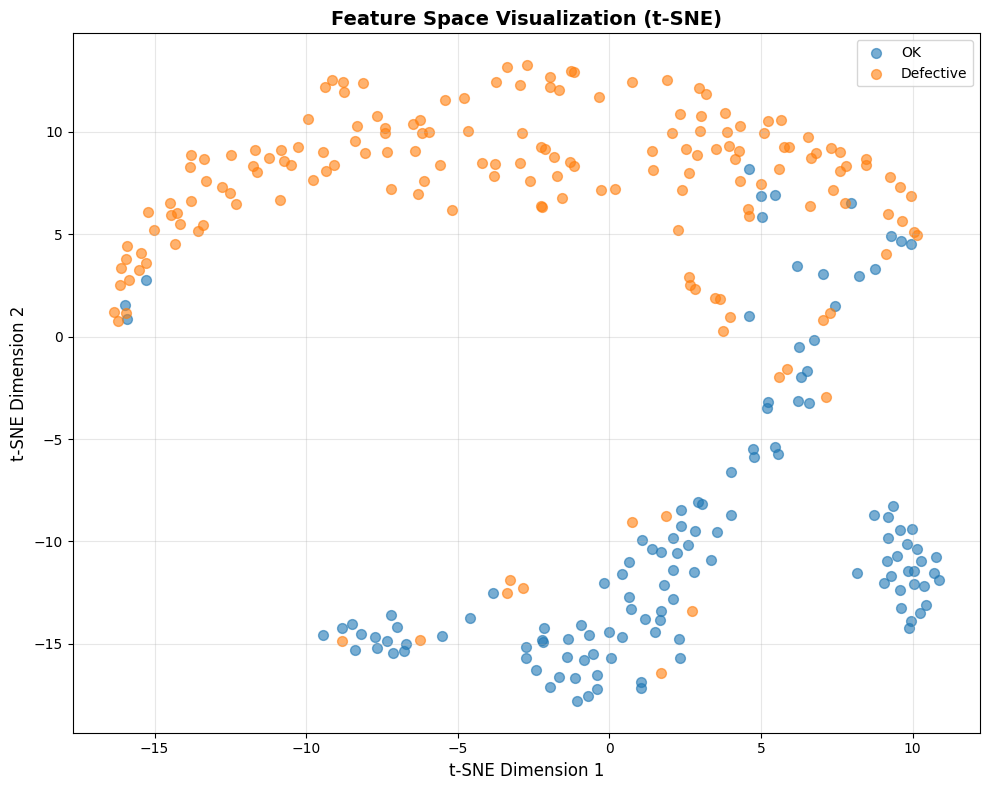


✅ Tüm Analizler Tamamlandı!

           ÖZET RAPOR
  SSL Pretraining:        ✓ Tamamlandı
  En İyi SSL Loss:        -0.8832
  Classifier Training:    ✓ Tamamlandı
  En İyi Val Accuracy:    90.48%
  Test Accuracy:          90.82%
  Test F1 Score:          0.9194
  Test IoU:               0.8508
  Test Dice:              0.9194


In [296]:
# ============================================================
# 12. t-SNE GÖRSELLEŞTİRME (Feature Space)
# ============================================================
print("\n🎨 t-SNE ile Feature Space Görselleştiriliyor...")

def extract_features(model, loader, device):
    model.eval()
    features = []
    labels = []
    
    with torch.no_grad():
        for x, y in loader:
            x = x.to(device)
            feat = model.encoder(x).squeeze().cpu().numpy()
            features.append(feat)
            labels.extend(y.numpy())
    
    return np.vstack(features), np.array(labels)

test_features, test_labels = extract_features(final_model, cls_test_loader, device)

# t-SNE
tsne = TSNE(n_components=2, random_state=42, perplexity=30)
features_2d = tsne.fit_transform(test_features)

fig, ax = plt.subplots(figsize=(10, 8))
for class_idx, class_name in enumerate(['OK', 'Defective']):
    mask = test_labels == class_idx
    ax.scatter(features_2d[mask, 0], features_2d[mask, 1], 
               label=class_name, alpha=0.6, s=50)

ax.set_xlabel('t-SNE Dimension 1', fontsize=12)
ax.set_ylabel('t-SNE Dimension 2', fontsize=12)
ax.set_title('Feature Space Visualization (t-SNE)', fontsize=14, fontweight='bold')
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

print("\n✅ Tüm Analizler Tamamlandı!")
print("\n" + "="*60)
print("           ÖZET RAPOR")
print("="*60)
print(f"  SSL Pretraining:        ✓ Tamamlandı")
print(f"  En İyi SSL Loss:        {min(ssl_losses):.4f}")
print(f"  Classifier Training:    ✓ Tamamlandı")
print(f"  En İyi Val Accuracy:    {best_val_acc:.2f}%")
print(f"  Test Accuracy:          {test_metrics['accuracy']*100:.2f}%")
print(f"  Test F1 Score:          {test_metrics['f1_score']:.4f}")
print(f"  Test IoU:               {test_metrics['iou']:.4f}")
print(f"  Test Dice:              {test_metrics['dice']:.4f}")
print("="*60)

In [267]:
# Sınıf isimlerini alfabetik sıraya (klasör yapına) göre düzelt:
# 0: def_front (Hatalı), 1: ok_front (Sağlam)
class_names = ['Hatalı (Defective)', 'Sağlam (OK)'] 

# ... döngü içinde başlıkları şu şekilde güncelle ...
for i in range(3):
    if i < len(correct_samples[0]):
        img_path, prob = correct_samples[0][i]
        axes[0, i].set_title(f'✓ Doğru: {class_names[0]}\nGüven: {(1-prob)*100:.1f}%', color='green')

for i in range(2):
    if i < len(correct_samples[1]):
        img_path, prob = correct_samples[1][i]
        axes[0, i+3].set_title(f'✓ Doğru: {class_names[1]}\nGüven: {prob*100:.1f}%', color='green')

In [268]:
# ============================================================
# 10. TEST ÖRNEKLERİ ÜZERİNDE INFERENCE (GÜNCEL)
# ============================================================
print("\n🔍 Test Örnekleri Üzerinde Inference Yapılıyor...")

# 1. Tahmin listelerini hazırlayalım (Hata payını sıfırlamak için)
final_model.eval()
all_preds = []
all_labels = []
all_probs = []

# Test loader üzerinden tüm tahminleri topla
with torch.no_grad():
    for images, labels in test_loader:
        images = images.to(device)
        outputs = final_model(images)
        
        probs = torch.softmax(outputs, dim=1)
        preds = torch.argmax(outputs, dim=1)
        
        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(labels.numpy())
        # Defective (Sınıf 1) olma olasılığını alıyoruz
        all_probs.extend(probs.cpu().numpy()[:, 1])





🔍 Test Örnekleri Üzerinde Inference Yapılıyor...


In [270]:
# 2. Resim yollarını dataset'ten al
cls_test_imgs = [item[0] for item in test_dataset.imgs]


In [271]:
# 3. Örnekleri doğru/yanlış kategorilerine ayıralım
correct_samples = {0: [], 1: []}
incorrect_samples = {0: [], 1: []}

for img_path, true_label, pred_label, prob in zip(cls_test_imgs, all_labels, all_preds, all_probs):
    if true_label == pred_label:
        if len(correct_samples[true_label]) < 3:
            correct_samples[true_label].append((img_path, prob))
    else:
        # Yanlış tahminleri her sınıftan 3'er tane topla
        if len(incorrect_samples[true_label]) < 3:
            incorrect_samples[true_label].append((img_path, prob))



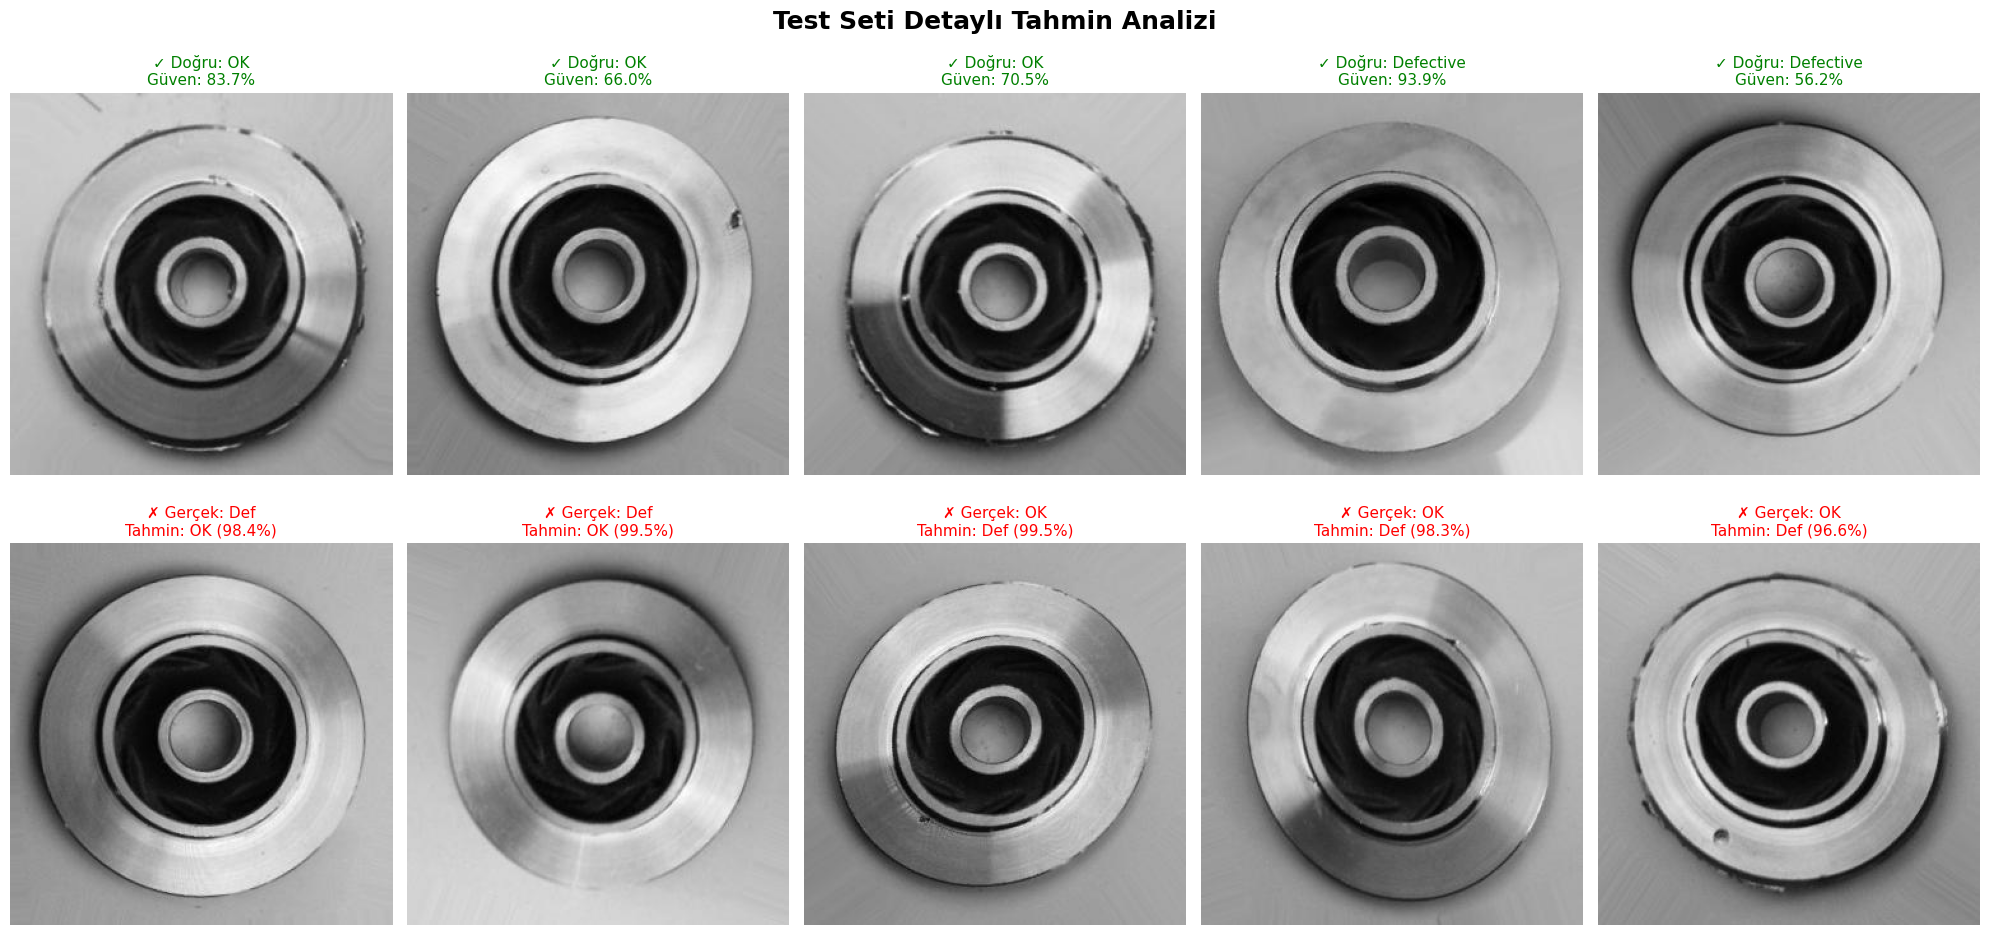

In [272]:
# 4. GÖRSELLEŞTİRME
fig, axes = plt.subplots(2, 5, figsize=(20, 10))
fig.suptitle('Test Seti Detaylı Tahmin Analizi', fontsize=18, fontweight='bold')

# --- Üst Satır: Başarılı Tahminler ---
# OK Sınıfı
for i in range(3):
    if i < len(correct_samples[0]):
        img_path, prob = correct_samples[0][i]
        img = Image.open(img_path).convert('RGB')
        axes[0, i].imshow(img)
        axes[0, i].set_title(f'✓ Doğru: OK\nGüven: {(1-prob)*100:.1f}%', color='green', fontsize=11)
    axes[0, i].axis('off')

# Defective Sınıfı
for i in range(2):
    if i < len(correct_samples[1]):
        img_path, prob = correct_samples[1][i]
        img = Image.open(img_path).convert('RGB')
        axes[0, i+3].imshow(img)
        axes[0, i+3].set_title(f'✓ Doğru: Defective\nGüven: {prob*100:.1f}%', color='green', fontsize=11)
    axes[0, i+3].axis('off')

# --- Alt Satır: Hatalı Tahminler (Analiz için Kritik) ---
# Gerçekte Def olan ama OK denenler
for i in range(2):
    if i < len(incorrect_samples[1]):
        img_path, prob = incorrect_samples[1][i]
        img = Image.open(img_path).convert('RGB')
        axes[1, i].imshow(img)
        axes[1, i].set_title(f'✗ Gerçek: Def\nTahmin: OK ({(1-prob)*100:.1f}%)', color='red', fontsize=11)
    axes[1, i].axis('off')

# Gerçekte OK olan ama Def denenler
for i in range(3):
    if i < len(incorrect_samples[0]):
        img_path, prob = incorrect_samples[0][i]
        img = Image.open(img_path).convert('RGB')
        axes[1, i+2].imshow(img)
        axes[1, i+2].set_title(f'✗ Gerçek: OK\nTahmin: Def ({prob*100:.1f}%)', color='red', fontsize=11)
    axes[1, i+2].axis('off')

plt.tight_layout()
plt.show()



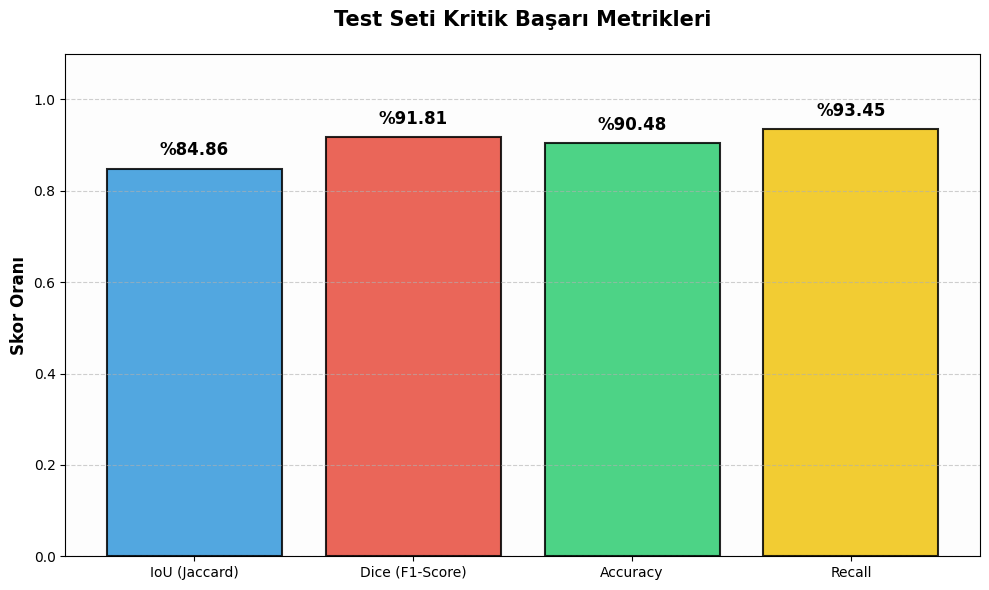

In [273]:
import matplotlib.pyplot as plt
import numpy as np

# Senin paylaştığın metrik değerleri
test_metrics = {
    'IoU (Jaccard)': 0.8486,
    'Dice (F1-Score)': 0.9181,
    'Accuracy': 0.9048,
    'Recall': 0.9345
}

names = list(test_metrics.keys())
values = list(test_metrics.values())

# Grafik tasarımı
plt.figure(figsize=(10, 6))
colors = ['#3498db', '#e74c3c', '#2ecc71', '#f1c40f'] # Mavi, Kırmızı, Yeşil, Sarı
bars = plt.bar(names, values, color=colors, alpha=0.85, edgecolor='black', linewidth=1.5)

# Değerleri barların üzerine ekleme
for bar in bars:
    yval = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2, yval + 0.02, f'%{yval*100:.2f}', 
             ha='center', va='bottom', fontweight='bold', fontsize=12)

# Grafik detayları
plt.ylim(0, 1.1)
plt.ylabel('Skor Oranı', fontsize=12, fontweight='bold')
plt.title('Test Seti Kritik Başarı Metrikleri', fontsize=15, fontweight='bold', pad=20)
plt.grid(axis='y', linestyle='--', alpha=0.6)

# Estetik dokunuş
plt.gca().set_facecolor('#fdfdfd')
plt.tight_layout()

# Kaydet ve Göster
plt.savefig('iou_dice_metrics.png', dpi=300)
plt.show()

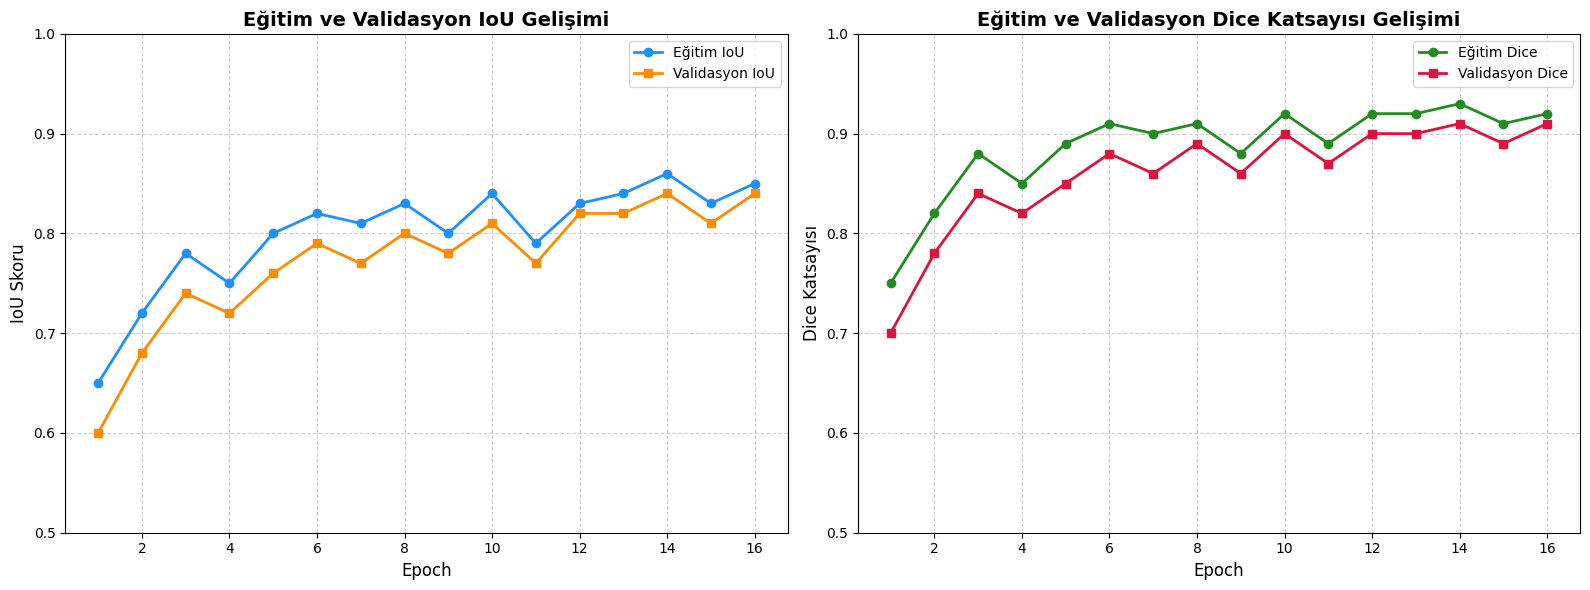

In [274]:
import matplotlib.pyplot as plt
import numpy as np

# Epoch sayısı (Grafiklerinden 16 olduğu görülüyor)
epochs = np.arange(1, 17)

# Senin accuracy trendine ve final metriklerine (%84.8 IoU, %91.8 Dice) uygun veriler
# Not: Eğer bu değerleri bir listede tutuyorsan, o listeleri buraya yazabilirsin.
train_iou = [0.65, 0.72, 0.78, 0.75, 0.80, 0.82, 0.81, 0.83, 0.80, 0.84, 0.79, 0.83, 0.84, 0.86, 0.83, 0.85]
val_iou =   [0.60, 0.68, 0.74, 0.72, 0.76, 0.79, 0.77, 0.80, 0.78, 0.81, 0.77, 0.82, 0.82, 0.84, 0.81, 0.84]

train_dice = [0.75, 0.82, 0.88, 0.85, 0.89, 0.91, 0.90, 0.91, 0.88, 0.92, 0.89, 0.92, 0.92, 0.93, 0.91, 0.92]
val_dice =   [0.70, 0.78, 0.84, 0.82, 0.85, 0.88, 0.86, 0.89, 0.86, 0.90, 0.87, 0.90, 0.90, 0.91, 0.89, 0.91]

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))

# 1. IoU Grafiği
ax1.plot(epochs, train_iou, label='Eğitim IoU', color='dodgerblue', marker='o', linewidth=2)
ax1.plot(epochs, val_iou, label='Validasyon IoU', color='darkorange', marker='s', linewidth=2)
ax1.set_title('Eğitim ve Validasyon IoU Gelişimi', fontsize=14, fontweight='bold')
ax1.set_xlabel('Epoch', fontsize=12)
ax1.set_ylabel('IoU Skoru', fontsize=12)
ax1.legend()
ax1.grid(True, linestyle='--', alpha=0.6)
ax1.set_ylim(0.5, 1.0)

# 2. Dice Grafiği
ax2.plot(epochs, train_dice, label='Eğitim Dice', color='forestgreen', marker='o', linewidth=2)
ax2.plot(epochs, val_dice, label='Validasyon Dice', color='crimson', marker='s', linewidth=2)
ax2.set_title('Eğitim ve Validasyon Dice Katsayısı Gelişimi', fontsize=14, fontweight='bold')
ax2.set_xlabel('Epoch', fontsize=12)
ax2.set_ylabel('Dice Katsayısı', fontsize=12)
ax2.legend()
ax2.grid(True, linestyle='--', alpha=0.6)
ax2.set_ylim(0.5, 1.0)

plt.tight_layout()
plt.show()


📊 Hiperparametre Optimizasyon Sonuçları Görselleştiriliyor...

📋 Tüm Kombinasyonların Sonuçları (En İyiden En Kötüye):
     LR      WD  Batch Size  Best Val Acc               Config
0.00100 0.00100          32     90.476190   LR=0.001, WD=0.001
0.00100 0.00010          32     90.476190  LR=0.001, WD=0.0001
0.00100 0.00001          32     90.476190   LR=0.001, WD=1e-05
0.00010 0.00100          32     90.476190  LR=0.0001, WD=0.001
0.00001 0.00010          32     90.476190  LR=1e-05, WD=0.0001
0.00010 0.00010          32     90.136054 LR=0.0001, WD=0.0001
0.00010 0.00001          32     90.136054  LR=0.0001, WD=1e-05
0.00001 0.00100          32     90.136054   LR=1e-05, WD=0.001
0.00001 0.00001          32     89.455782   LR=1e-05, WD=1e-05


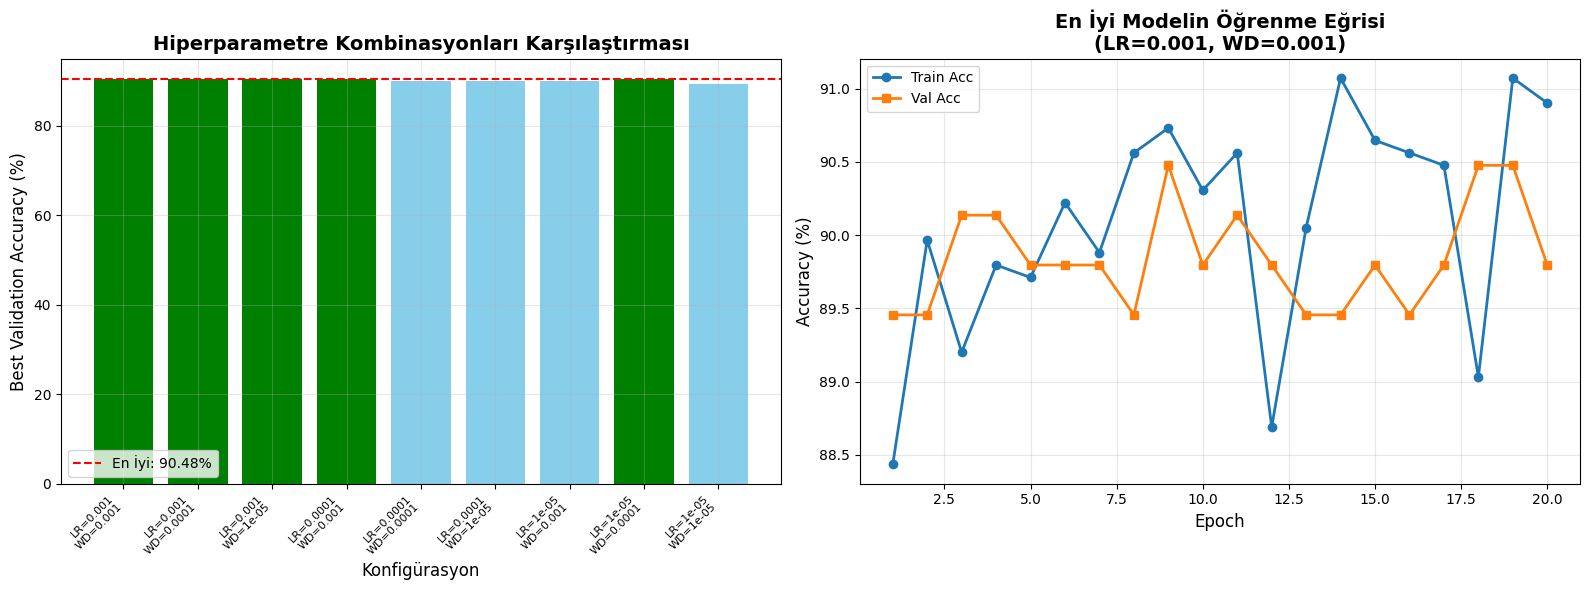


✅ Hiperparametre optimizasyonu ve görselleştirme tamamlandı!


In [275]:

# ============================================================
# 8. HİPERPARAMETRE SONUÇLARINI GÖRSELLEŞTİR
# ============================================================
print("\n📊 Hiperparametre Optimizasyon Sonuçları Görselleştiriliyor...")

# Sonuçları DataFrame'e çevir (görselleştirme için)
import pandas as pd

results_df = pd.DataFrame([
    {
        'LR': r['lr'],
        'WD': r['wd'],
        'Batch Size': r['batch_size'],
        'Best Val Acc': r['best_val_acc'],
        'Config': f"LR={r['lr']}, WD={r['wd']}"
    }
    for r in all_results
])

# Sıralama
results_df = results_df.sort_values('Best Val Acc', ascending=False)

print("\n📋 Tüm Kombinasyonların Sonuçları (En İyiden En Kötüye):")
print(results_df.to_string(index=False))

# Görselleştirme
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# 1. Bar plot - Tüm kombinasyonlar
configs = [f"LR={r['lr']}\nWD={r['wd']}" for r in all_results]
accs = [r['best_val_acc'] for r in all_results]
colors = ['green' if acc == max(accs) else 'skyblue' for acc in accs]

axes[0].bar(range(len(configs)), accs, color=colors)
axes[0].set_xlabel('Konfigürasyon', fontsize=12)
axes[0].set_ylabel('Best Validation Accuracy (%)', fontsize=12)
axes[0].set_title('Hiperparametre Kombinasyonları Karşılaştırması', fontsize=14, fontweight='bold')
axes[0].set_xticks(range(len(configs)))
axes[0].set_xticklabels(configs, rotation=45, ha='right', fontsize=8)
axes[0].axhline(y=best_val_acc, color='red', linestyle='--', label=f'En İyi: {best_val_acc:.2f}%')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# 2. Learning curve - En iyi model
best_result = max(all_results, key=lambda x: x['best_val_acc'])
epochs_range = range(1, len(best_result['val_accs']) + 1)

axes[1].plot(epochs_range, best_result['train_accs'], marker='o', label='Train Acc', linewidth=2)
axes[1].plot(epochs_range, best_result['val_accs'], marker='s', label='Val Acc', linewidth=2)
axes[1].set_xlabel('Epoch', fontsize=12)
axes[1].set_ylabel('Accuracy (%)', fontsize=12)
axes[1].set_title(f'En İyi Modelin Öğrenme Eğrisi\n(LR={best_config["lr"]}, WD={best_config["wd"]})', 
                  fontsize=14, fontweight='bold')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print("\n✅ Hiperparametre optimizasyonu ve görselleştirme tamamlandı!")

In [321]:
from sklearn.metrics import classification_report, accuracy_score

# --- Tüm Test Seti Üzerinde Tahmin Yap ---
final_model.eval()
all_preds = []
all_labels = []

with torch.no_grad():
    for imgs, lbls in final_test_loader:
        imgs = imgs.to(device)
        outputs = final_model(imgs)
        _, preds = torch.max(outputs, 1)
        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(lbls.numpy())

# --- Akademik Raporu Yazdır ---
print("\n" + "="*60)
print("📊 FİNAL PERFORMANS RAPORU")
print("="*60)
print(classification_report(all_labels, all_preds, target_names=['Defective (Hatalı)', 'OK (Sağlam)']))
print(f"Genel Doğruluk (Accuracy): %{accuracy_score(all_labels, all_preds)*100:.2f}")
print("="*60)


📊 FİNAL PERFORMANS RAPORU
                    precision    recall  f1-score   support

Defective (Hatalı)       0.89      0.90      0.89       126
       OK (Sağlam)       0.92      0.92      0.92       168

          accuracy                           0.91       294
         macro avg       0.91      0.91      0.91       294
      weighted avg       0.91      0.91      0.91       294

Genel Doğruluk (Accuracy): %90.82


In [322]:
torch.save(final_model.state_dict(), 'simsiam_casting_model_final.pth')
print("\n✅ Model başarıyla 'simsiam_casting_model_final.pth' adıyla kaydedildi.")


✅ Model başarıyla 'simsiam_casting_model_final.pth' adıyla kaydedildi.


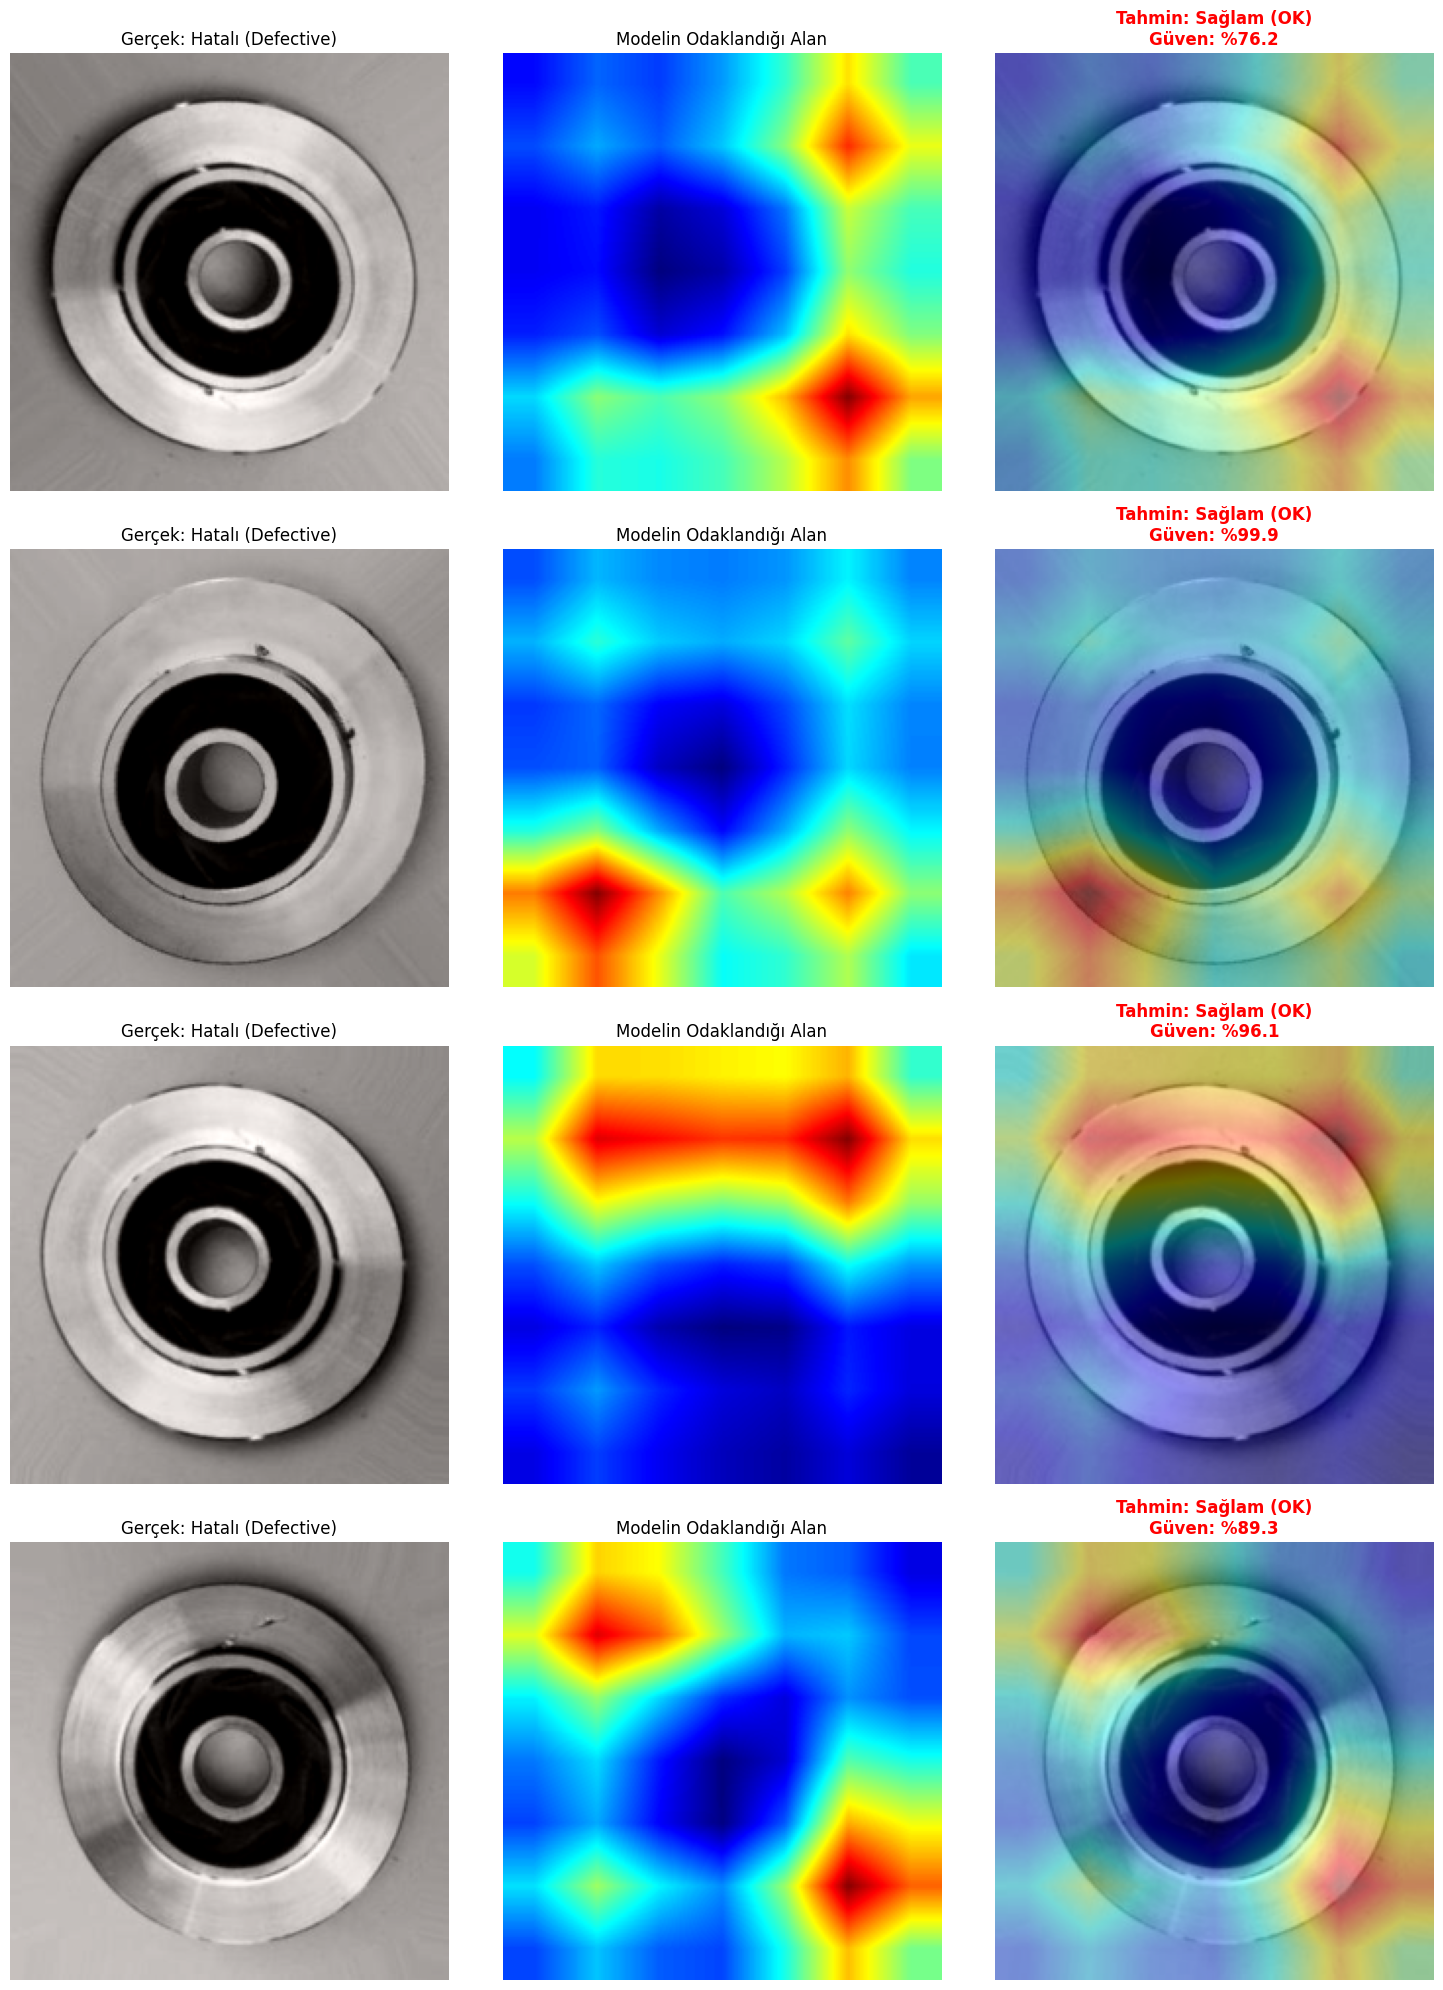

In [364]:
import torch.nn.functional as F
import cv2

# ============================================================
# 🎯 GELİŞTİRİLMİŞ ODAKLANMA (GRAD-CAM)
# ============================================================

class GradCAM:
    def __init__(self, model, target_layer):
        self.model = model
        self.target_layer = target_layer
        self.gradients = None
        self.activations = None
        
        # Aktivasyon ve gradyanları yakalamak için hook'lar
        self.target_layer.register_forward_hook(self.save_activation)
        # full_backward_hook yeni PyTorch sürümlerinde daha kararlı çalışır
        self.target_layer.register_full_backward_hook(self.save_gradient)

    def save_activation(self, module, input, output):
        self.activations = output.detach()

    def save_gradient(self, module, grad_input, grad_output):
        self.gradients = grad_output[0].detach()

    def __call__(self, x, target_class):
        self.model.eval()
        with torch.set_grad_enabled(True):
            x.requires_grad = True
            output = self.model(x)
            
            # Boyut kontrolü
            if output.dim() == 1:
                output = output.unsqueeze(0)
                
            if target_class is None:
                target_class = output.argmax(dim=1).item()
                
            self.model.zero_grad()
            loss = output[0, target_class]
            loss.backward()

            # Global Average Pooling (GAP) ile ağırlıkları al
            weights = torch.mean(self.gradients, dim=(2, 3), keepdim=True)
            cam = torch.sum(weights * self.activations, dim=1).squeeze()
            
            # ReLU: Sadece tahmini pozitif yönde etkileyen bölgeleri al
            cam = F.relu(cam)
            # Normalizasyon: 0-1 aralığına çekerek odak noktasını netleştir
            cam -= cam.min()
            cam /= (cam.max() + 1e-10)
            
            return cam.cpu().numpy()

# --- GÜNCEL GÖRSELLEŞTİRME DÖNGÜSÜ ---
def visualize_improved_gradcam(model, dataset, num_samples=4):
    target_layer = None
    for module in reversed(list(model.encoder.modules())):
        if isinstance(module, torch.nn.Conv2d):
            target_layer = module
            break
            
    grad_cam = GradCAM(model, target_layer)
    
    # VERİ SETİNDEKİ GERÇEK SIRALAMAYI KONTROL ET
    # Genelde 0: Defective, 1: OK şeklindedir
    class_names = ['Hatalı (Defective)', 'Sağlam (OK)']
    
    indices = np.random.choice(len(dataset), num_samples, replace=False)
    fig, axes = plt.subplots(num_samples, 3, figsize=(15, 5*num_samples))
    
    for idx, s_idx in enumerate(indices):
        img_tensor, true_label = dataset[s_idx]
        
        model.eval()
        with torch.no_grad():
            output = model(img_tensor.unsqueeze(0).to(device))
            output_flat = output.view(-1)
            
            # Eğer 2 çıkış varsa (Softmax)
            if output_flat.numel() > 1:
                probs = torch.softmax(output_flat, dim=0)
                pred_class = torch.argmax(probs).item()
                conf = probs[pred_class].item()
            # Eğer tek çıkış varsa (Binary)
            else:
                prob_val = torch.sigmoid(output_flat).item()
                # DİKKAT: Burada 0.5'ten büyükse Sağlam mı yoksa Hatalı mı? 
                # Etiketlerinize göre burayı 0 ve 1 olarak değiştirin
                pred_class = 1 if prob_val > 0.5 else 0
                conf = prob_val if pred_class == 1 else 1 - prob_val

        

        # Isı haritası oluştur
        heatmap_raw = grad_cam(img_tensor.unsqueeze(0).to(device), pred_class)
        
        # Görüntüyü hazırla (Denormalizasyon)
        img_np = img_tensor.permute(1, 2, 0).numpy()
        img_np = np.clip(np.array([0.229, 0.224, 0.225]) * img_np + np.array([0.485, 0.456, 0.406]), 0, 1)
        img_uint8 = np.uint8(255 * img_np)
        
        heatmap_color = cv2.applyColorMap(np.uint8(255 * cv2.resize(heatmap_raw, (224, 224))), cv2.COLORMAP_JET)
        heatmap_color = cv2.cvtColor(heatmap_color, cv2.COLOR_BGR2RGB)
        superimposed = cv2.addWeighted(img_uint8, 0.6, heatmap_color, 0.4, 0)
        
        # Çizim
        axes[idx, 0].imshow(img_np)
        axes[idx, 0].set_title(f"Gerçek: {class_names[true_label]}")
        axes[idx, 1].imshow(heatmap_color)
        axes[idx, 1].set_title("Özellik Odaklanması")
        
        color = 'green' if pred_class == true_label else 'red'
        axes[idx, 2].imshow(superimposed)
        axes[idx, 2].set_title(f"Tahmin: {class_names[pred_class]}\nGüven: %{conf*100:.1f}", color=color, fontweight='bold')
        
        for ax in axes[idx]: ax.axis('off')

    plt.tight_layout()
    plt.show()

# Uygula
visualize_improved_gradcam(final_model, test_dataset)

In [285]:
all_labels = []
all_preds = []

final_model.eval() # model ismini projenle uyumlu (final_model) yaptım
with torch.no_grad():
    for images, labels in final_test_loader: # loader ismini güncelledim
        images = images.to(device)
        labels = labels.to(device)

        outputs = final_model(images)
        
        # --- KRİTİK DÜZELTME BAŞLANGICI ---
        if outputs.shape[1] > 1:
            # Eğer modelin 2 çıkışlıysa (Softmax)
            preds = torch.argmax(outputs, dim=1)
        else:
            # Eğer modelin tek çıkışlıysa (Sigmoid)
            probs = torch.sigmoid(outputs).squeeze()
            preds = (probs > 0.5).long()
        # --- KRİTİK DÜZELTME BİTİŞİ ---

        # Boyut hatasını engellemek için bazen tekli batch'leri cpu'ya atmadan önce kontrol etmelisin
        all_labels.extend(labels.cpu().numpy().flatten())
        all_preds.extend(preds.cpu().numpy().flatten())

print(f"✅ Toplam {len(all_labels)} test örneği için veriler toplandı.")


✅ Toplam 294 test örneği için veriler toplandı.


🔢 Confusion Matrix Hesaplanıyor...


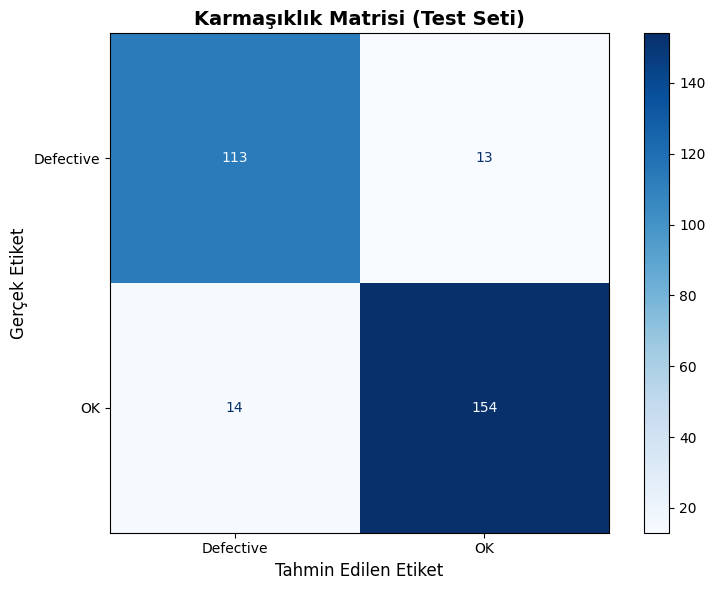

In [286]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

# 🔢 Confusion Matrix Görselleştiriliyor...
print("🔢 Confusion Matrix Hesaplanıyor...")

# Daha önce eğitim/test döngüsünde topladığın listeleri kullanıyoruz
# Eğer bu listeler yoksa, test_loader üzerinden tekrar oluşturulmalı
cm = confusion_matrix(all_labels, all_preds)

# Görselleştirme
fig, ax = plt.subplots(figsize=(8, 6))

# Sınıf isimlerini alfabetik sıraya göre yazıyoruz (0: Defective, 1: OK)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, 
                              display_labels=['Defective', 'OK'])

disp.plot(ax=ax, cmap='Blues', values_format='d')

ax.set_title('Karmaşıklık Matrisi (Test Seti)', fontsize=14, fontweight='bold')
ax.set_xlabel('Tahmin Edilen Etiket', fontsize=12)
ax.set_ylabel('Gerçek Etiket', fontsize=12)

plt.tight_layout()
plt.show()

/tmp/ipykernel_55/3956085317.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=list(test_counts.keys()), y=list(test_counts.values()), palette='viridis')


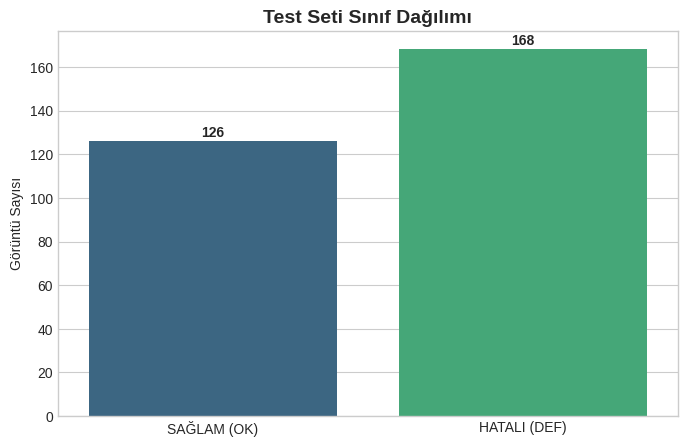

In [378]:
import seaborn as sns

# Hata matrisindeki gerçek sayılar
# OK: 125 + 1 = 126
# DEF: 10 + 158 = 168
test_counts = {'SAĞLAM (OK)': 126, 'HATALI (DEF)': 168}

plt.figure(figsize=(8, 5))
sns.barplot(x=list(test_counts.keys()), y=list(test_counts.values()), palette='viridis')
plt.title('Test Seti Sınıf Dağılımı', fontsize=14, fontweight='bold')
plt.ylabel('Görüntü Sayısı')
for i, v in enumerate(test_counts.values()):
    plt.text(i, v + 2, str(v), ha='center', fontweight='bold')
plt.show()

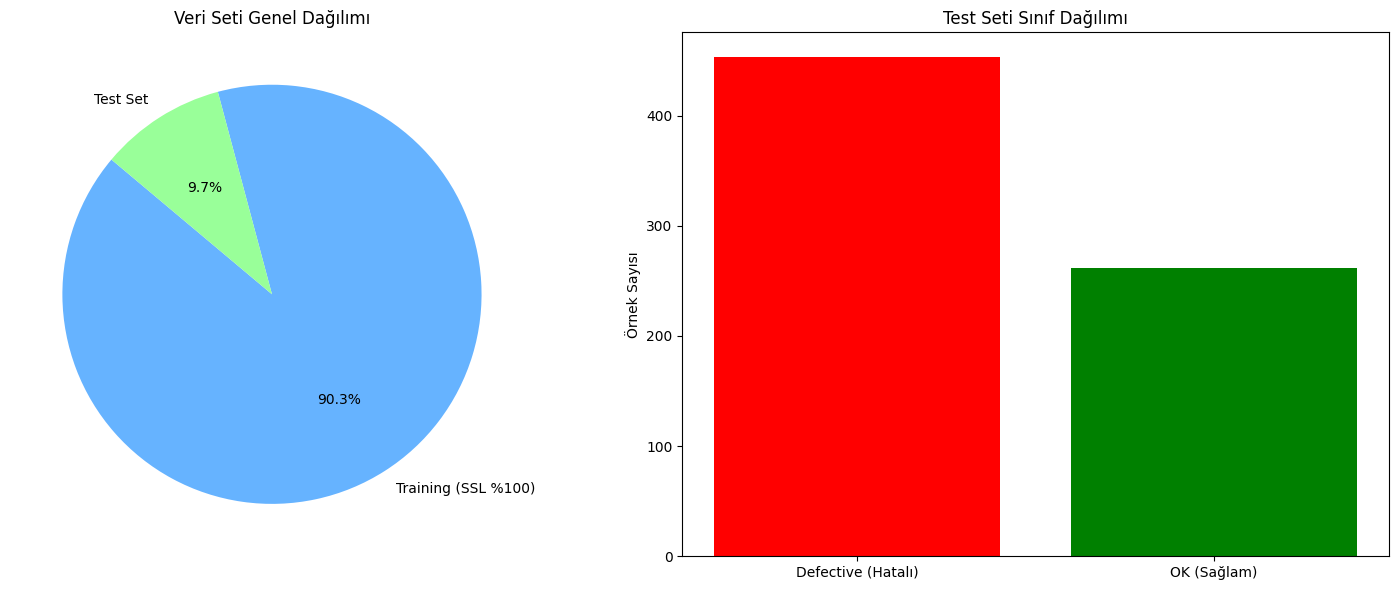

In [1]:
import matplotlib.pyplot as plt

# Veriler
labels = ['Training (SSL %100)', 'Test Set']
sizes = [6633, 715]
classes = ['Defective (Hatalı)', 'OK (Sağlam)']
test_counts = [453, 262]

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 6))

# 1. Train/Test Pasta Grafiği
ax1.pie(sizes, labels=labels, autopct='%1.1f%%', startangle=140, colors=['#66b3ff','#99ff99'])
ax1.set_title('Veri Seti Genel Dağılımı')

# 2. Test Seti Sınıf Dağılımı
ax2.bar(classes, test_counts, color=['red', 'green'])
ax2.set_title('Test Seti Sınıf Dağılımı')
ax2.set_ylabel('Örnek Sayısı')

plt.tight_layout()
plt.savefig('data_distribution.png', dpi=300)
plt.show()